# K-IFRS LangGraph RAG Chain

Hybrid Retriever (BM25 0.4 + Dense 0.6) → Reranker → LangGraph RAG 체인

- **Retriever**: QdrantDenseRetriever + BM25Retriever → EnsembleRetriever (Top-30)
- **Reranker**: LocalReranker (bge-reranker-v2-m3-ko) 또는 CohereReranker (Top-5)
- **LLM**: Claude (LLM_MODEL 환경변수)
- **Graph**: retrieve → rerank → generate

In [ ]:
import os
import json
import glob
import time
import pickle
import hashlib
from pathlib import Path

from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_upstage import UpstageEmbeddings
from langchain_anthropic import ChatAnthropic
from qdrant_client import QdrantClient
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

from search.config import QDRANT_PATH, CHUNKS_DIR, CHILD_COLLECTION, PARENT_COLLECTION, MODEL_NAME
from search.retriever import QdrantDenseRetriever, load_child_documents, kiwi_tokenize
from search.reranker import get_reranker

load_dotenv()
print("패키지 로드 완료")

## 1. 설정

In [ ]:
RETRIEVAL_K = 50    # Hybrid 검색 후보 수
RERANK_TOP_N = 10    # Reranker 후 LLM 전달 수
TOP_K = RERANK_TOP_N  # backward compat

## 2. Hybrid Retriever 구성

In [6]:
# BM25 캐시 관리
BM25_CACHE_DIR = Path(".")
BM25_PKL_PATH = BM25_CACHE_DIR / "bm25_retriever.pkl"
BM25_META_PATH = BM25_CACHE_DIR / "bm25_cache_meta.json"


def _docs_fingerprint(docs: list[Document]) -> str:
    """문서 수 + 첫/마지막 문서 내용으로 MD5 fingerprint 생성"""
    h = hashlib.md5()
    h.update(str(len(docs)).encode())
    if docs:
        h.update(docs[0].page_content.encode())
        h.update(docs[-1].page_content.encode())
    return h.hexdigest()


def load_or_build_bm25(
    docs: list[Document], preprocess_func, k: int
) -> BM25Retriever:
    fingerprint = _docs_fingerprint(docs)

    # 캐시 유효성 검사
    if BM25_PKL_PATH.exists() and BM25_META_PATH.exists():
        meta = json.loads(BM25_META_PATH.read_text(encoding="utf-8"))
        if meta.get("fingerprint") == fingerprint:
            print(f"  캐시 적중 — {BM25_PKL_PATH} 로드 중...")
            t0 = time.time()
            with open(BM25_PKL_PATH, "rb") as f:
                retriever = pickle.load(f)
            retriever.k = k
            print(f"  BM25 캐시 로드 완료 ({time.time() - t0:.1f}초)")
            return retriever
        else:
            print("  캐시 fingerprint 불일치 — 재빌드합니다.")

    # 캐시 미스: 새로 빌드
    print(f"  BM25 인덱스 빌드 중... (문서 {len(docs)}개)")
    t0 = time.time()
    retriever = BM25Retriever.from_documents(
        docs, preprocess_func=preprocess_func, k=k
    )
    elapsed = time.time() - t0
    print(f"  BM25 인덱스 빌드 완료 ({elapsed:.1f}초)")

    # 캐시 저장
    with open(BM25_PKL_PATH, "wb") as f:
        pickle.dump(retriever, f)
    BM25_META_PATH.write_text(
        json.dumps({"fingerprint": fingerprint, "doc_count": len(docs)},
                   ensure_ascii=False),
        encoding="utf-8",
    )
    print(f"  캐시 저장 완료 — {BM25_PKL_PATH}")
    return retriever


print("load_or_build_bm25 정의 완료")

load_or_build_bm25 정의 완료


In [7]:
# 초기화
print("[1/5] 임베딩 모델 초기화...")
embeddings = UpstageEmbeddings(
    model=MODEL_NAME,
    upstage_api_key=os.getenv("UPSTAGE_API_KEY"),
)

print("[2/5] Qdrant 연결...")
client = QdrantClient(path=QDRANT_PATH)
child_count = client.count(CHILD_COLLECTION).count
print(f"  Child 포인트: {child_count}개")

print("[3/5] BM25 인덱스 구축...")
docs = load_child_documents(CHUNKS_DIR)
print(f"  LangChain Document: {len(docs)}개")
bm25_retriever = load_or_build_bm25(docs, preprocess_func=kiwi_tokenize, k=RETRIEVAL_K)

print("[4/5] Hybrid Retriever 구성...")
dense_retriever = QdrantDenseRetriever(
    client=client, embeddings=embeddings,
    collection_name=CHILD_COLLECTION, k=RETRIEVAL_K,
)
hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
    weights=[0.4, 0.6],
)

print("[5/5] Reranker 초기화...")
reranker = get_reranker()  # RERANKER_TYPE 환경변수 참조
print(f"  Reranker: {type(reranker).__name__}")
print("초기화 완료")

[1/5] 임베딩 모델 초기화...
[2/5] Qdrant 연결...
  Child 포인트: 12313개
[3/5] BM25 인덱스 구축...
  LangChain Document: 12457개
  캐시 적중 — bm25_retriever.pkl 로드 중...
  BM25 캐시 로드 완료 (0.5초)
[4/5] Hybrid Retriever 구성...
[5/5] Reranker 초기화...
  Reranker: CohereReranker
초기화 완료


## 3. LangGraph RAG Chain

In [8]:
# LLM
llm_model = os.getenv("LLM_MODEL", "claude-haiku-4-5-20251001")
llm = ChatAnthropic(
    model=llm_model,
    temperature=0.1,
    anthropic_api_key=os.getenv("ANTHROPIC_API_KEY"),
)
print(f"LLM 초기화 완료: {llm_model}")

LLM 초기화 완료: claude-haiku-4-5-20251001


In [9]:
# State 정의
class RAGState(TypedDict):
    query: str
    retrieved_docs: list[Document]  # Hybrid 검색 결과 (최대 30)
    context: list[Document]          # Rerank 후 상위 문서 (5)
    answer: str

In [10]:
# 노드 1: retrieve
def retrieve(state: RAGState) -> RAGState:
    query = state["query"]
    results = hybrid_retriever.invoke(query)
    # 빈 문서 필터링 후 상위 RETRIEVAL_K개
    retrieved = [d for d in results if d.page_content.strip()][:RETRIEVAL_K]
    return {"retrieved_docs": retrieved}

In [11]:
# 노드 2: rerank
def rerank(state: RAGState) -> RAGState:
    query = state["query"]
    docs = state["retrieved_docs"]
    reranked = reranker.rerank(query, docs, top_n=RERANK_TOP_N)
    return {"context": reranked}

In [12]:
# context 포맷팅 함수
def format_context(docs: list[Document]) -> str:
    parts = []
    for i, doc in enumerate(docs, 1):
        m = doc.metadata
        std_id = m.get("standard_id", "?")
        section = m.get("section_type", "?")
        para = m.get("para_number", "?")
        score = m.get("rerank_score")

        section_label = {
            "main": "본문", "ag": "적용지침",
            "bc": "결론도출근거", "ie": "사례",
        }.get(section, section)

        header = f"[{i}] {std_id} | {section_label} | 문단 {para}"
        if score is not None:
            header += f" | relevance={score:.4f}"
        parts.append(f"{header}\n{doc.page_content}")
    return "\n\n---\n\n".join(parts)

In [13]:
# K-IFRS 특화 시스템 프롬프트
SYSTEM_PROMPT = """당신은 K-IFRS(한국채택국제회계기준) 전문 회계 자문 AI입니다.

아래 규칙을 반드시 준수하세요:
1. 반드시 제공된 기준서 내용만을 근거로 답변하세요.
2. 답변 시 해당 문단 번호를 인용하세요. (예: "문단 62에 따르면...")
3. 제공된 내용으로 답변할 수 없는 경우, 솔직하게 "제공된 기준서에 해당 내용이 없습니다"라고 답변하세요.
4. 답변은 명확하고 구조적으로 작성하세요."""


# 노드 3: generate
def generate(state: RAGState) -> RAGState:
    query = state["query"]
    context = state["context"]
    context_text = format_context(context)

    user_message = f"""다음은 K-IFRS 기준서에서 검색된 관련 내용입니다.

<context>
{context_text}
</context>

질문: {query}"""

    response = llm.invoke([
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_message},
    ])
    return {"answer": response.content}

In [14]:
# LangGraph 구성
graph_builder = StateGraph(RAGState)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("rerank", rerank)
graph_builder.add_node("generate", generate)
graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "rerank")
graph_builder.add_edge("rerank", "generate")
graph_builder.add_edge("generate", END)

rag_chain = graph_builder.compile()
print("RAG Chain 구성 완료: START → retrieve → rerank → generate → END")

RAG Chain 구성 완료: START → retrieve → rerank → generate → END


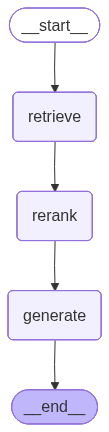

In [15]:
# 그래프 시각화
from IPython.display import Image, display

try:
    display(Image(rag_chain.get_graph().draw_mermaid_png()))
except Exception:
    print(rag_chain.get_graph().draw_mermaid())

## 4. 테스트 (5개 쿼리)

In [16]:
QUERIES = [
    "유형자산의 감가상각 방법에는 어떤 것들이 있나요?",
    "금융자산의 기대신용손실은 어떻게 측정하나요?",
    "수행의무를 식별하고 거래가격을 배분하는 기준은?",
    "사용권자산과 리스부채의 최초 측정 방법은?",
    "연결재무제표 작성 시 지배력 판단 기준은?",
]

In [17]:
from IPython.display import Markdown

In [18]:
result = rag_chain.invoke({"query": QUERIES[2]})
display(Markdown(result['answer']))

# 수행의무 식별 및 거래가격 배분 기준

## 1. 수행의무 식별 기준

K-IFRS 1115에서 수행의무는 다음 두 가지 조건을 모두 충족해야 합니다:

**문단 27⑴ (효익 기준)**
- 고객이 재화나 용역 그 자체에서 효익을 얻을 수 있거나
- 고객이 쉽게 구할 수 있는 다른 자원과 함께하여 효익을 얻을 수 있어야 함

**문단 27⑵ (식별 기준)**
- 그 약속을 계약 내의 다른 약속과 별도로 식별해 낼 수 있어야 함

---

## 2. 거래가격 배분의 기본 원칙

**문단 74**
거래가격은 **상대적 개별 판매가격을 기준**으로 계약에서 식별된 각 수행의무에 배분합니다.

**문단 76**
거래가격을 배분하기 위하여:
- 계약 개시시점에 각 수행의무의 대상인 구별되는 재화나 용역의 **개별 판매가격을 산정**
- 이 개별 판매가격에 **비례하여 거래가격을 배분**

---

## 3. 개별 판매가격 산정 방법

**문단 77~79**

| 방법 | 내용 |
|------|------|
| **직접 관측** (문단 77) | 기업이 보통 재화나 용역을 별도로 판매할 때의 가격 |
| **시장평가 조정 접근법** (문단 79⑴) | 비슷한 재화나 용역의 시장가격을 조정하여 추정 |
| **예상원가 이윤 가산 접근법** (문단 79⑵) | 예상 원가에 적절한 이윤을 가산하여 추정 |
| **잔여접근법** (문단 79⑶) | 거래가격에서 다른 수행의무의 개별 판매가격을 차감 |

---

## 4. 특수한 배분 규칙

### 할인액의 배분 (문단 81~83)

**문단 82**
할인액이 계약의 특정 수행의무에만 관련된다는 **관측 가능한 증거**가 있으면, 그 수행의무에만 할인액을 배분할 수 있습니다.

**IE170 사례**
기업이 보통 제품 B와 C를 함께 60원에, 제품 A를 40원에 판매하는 경우, 전체 할인액을 제품 B와 C에만 배분할 수 있습니다.

### 변동대가의 배분 (문단 84~86)

**문단 85**
변동대가(금액)를 특정 수행의무에만 배분할 수 있는 조건:
- ⑴ 변동 지급액이 그 수행의무의 결과와 **특정적으로 관련**
- ⑵ 변동대가를 그 수행의무에만 배분하는 것이 **배분 목적에 부합**

**IE180 사례**
판매기준 로열티(변동대가)가 특정 라이선스 이전과 특정적으로 관련되면, 그 라이선스에만 배분합니다.

---

## 5. 배분 목적

**문단 73**
거래가격 배분의 목적은 **기업이 고객에게 약속한 재화나 용역을 이전하고 그 대가로 받을 권리를 갖게 될 것으로 예상하는 금액**을 충실하게 나타내는 것입니다.

In [19]:
client.close()
print("Qdrant 연결 종료")

Qdrant 연결 종료
